# 04. Scoreboard & Visualization

**Phase 5-6**: 결과 통합 → 차트 5종 → 통계 검증 → 스코어보드

**사전 조건**: `01`, `02`, `03` 노트북 실행 완료

---

## 0. 환경 설정 & 데이터 로드

In [5]:
# ============================================================
# 0-1. 마운트 & 의존성
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats as sp_stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 (Colab)
!apt-get -qq install fonts-nanum
fm._load_fontmanager(try_read_cache=False)
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

BASE = '/content/drive/MyDrive/capstone/dsc'
RESULTS_DIR = f'{BASE}/results'
CHART_DIR = f'{RESULTS_DIR}/charts'
os.makedirs(CHART_DIR, exist_ok=True)

print('환경 설정 완료')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
환경 설정 완료


In [6]:
# ============================================================
# 0-2. 결과 로드 & 병합
# ============================================================
df_dsc = pd.read_csv(f'{RESULTS_DIR}/dsc_scores.csv')
df_perf = pd.read_csv(f'{RESULTS_DIR}/model_performance.csv')

print(f'DSC 점수: {df_dsc.shape}')
print(f'모델 성능: {df_perf.shape}')

# 병합 (DSC + 모델 성능)
df_merged = df_perf.merge(
    df_dsc,
    on=['dataset', 'polluter', 'level'],
    how='left',
)

df_merged.to_csv(f'{RESULTS_DIR}/merged_results.csv', index=False)
print(f'병합 결과: {df_merged.shape}')
print(f'저장: {RESULTS_DIR}/merged_results.csv')

df_merged.head()

DSC 점수: (87, 14)
모델 성능: (435, 7)
병합 결과: (435, 18)
저장: /content/drive/MyDrive/capstone/dsc/results/merged_results.csv


,dataset,polluter,level,model,accuracy,f1_macro,auc_roc,score,grade,completeness,uniqueness,validity,consistency,outlier_ratio,class_balance,feature_correlation,label_consistency,feature_informativeness
0,SouthGermanCredit,class_balance,0.1,LogisticRegression,0.740,0.6961,0.7813,75.09,B,1.0,1.0,1.0,1.0,0.9313,0.9,1.0,0.1111,0.4211
1,SouthGermanCredit,class_balance,0.1,MLP,0.740,0.6988,0.7398,75.09,B,1.0,1.0,1.0,1.0,0.9313,0.9,1.0,0.1111,0.4211
2,SouthGermanCredit,class_balance,0.1,RandomForest,0.735,0.6992,0.7781,75.09,B,1.0,1.0,1.0,1.0,0.9313,0.9,1.0,0.1111,0.4211
3,SouthGermanCredit,class_balance,0.1,SVC,0.725,0.6925,0.7551,75.09,B,1.0,1.0,1.0,1.0,0.9313,0.9,1.0,0.1111,0.4211
4,SouthGermanCredit,class_balance,0.1,XGBoost,0.675,0.6339,0.7482,75.09,B,1.0,1.0,1.0,1.0,0.9313,0.9,1.0,0.1111,0.4211


## 1. 차트 1: DSC Score vs F1-score 산점도 (핵심 증거)

X축: DSC Score, Y축: F1-score  
피어슨/스피어만 상관계수 표시, 모델별 색상 구분

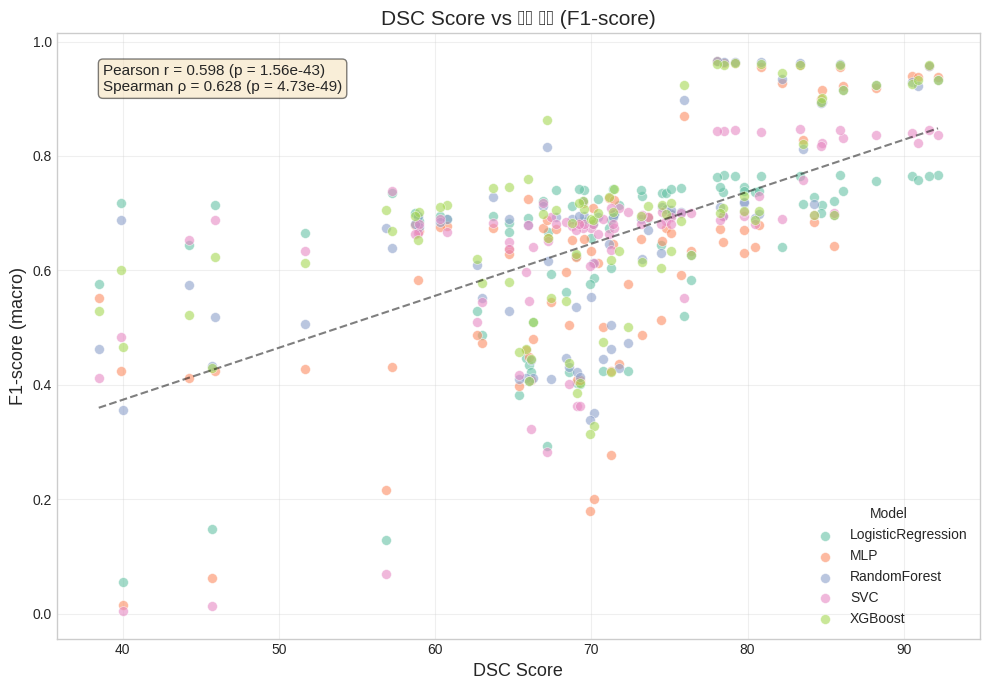

Pearson r = 0.5980, Spearman ρ = 0.6278


In [7]:
# ============================================================
# Chart 1: DSC Score vs F1-score Scatter
# ============================================================
fig, ax = plt.subplots(figsize=(10, 7))

models = df_merged['model'].unique()
colors = sns.color_palette('Set2', len(models))

for model, color in zip(models, colors):
    subset = df_merged[df_merged['model'] == model]
    ax.scatter(subset['score'], subset['f1_macro'],
               label=model, color=color, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

# 회귀선
x = df_merged['score'].values
y = df_merged['f1_macro'].values
mask = ~(np.isnan(x) | np.isnan(y))
x, y = x[mask], y[mask]

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, p(x_line), 'k--', alpha=0.5, linewidth=1.5)

# 상관계수
r_pearson, p_pearson = sp_stats.pearsonr(x, y)
r_spearman, p_spearman = sp_stats.spearmanr(x, y)

textstr = (f'Pearson r = {r_pearson:.3f} (p = {p_pearson:.2e})\n'
           f'Spearman ρ = {r_spearman:.3f} (p = {p_spearman:.2e})')
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('DSC Score', fontsize=13)
ax.set_ylabel('F1-score (macro)', fontsize=13)
ax.set_title('DSC Score vs 모델 성능 (F1-score)', fontsize=15)
ax.legend(title='Model', loc='lower right')
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f'{CHART_DIR}/chart1_scatter_dsc_vs_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pearson r = {r_pearson:.4f}, Spearman ρ = {r_spearman:.4f}')

## 2. 차트 2: 오염 강도별 DSC & F1 하락 라인 차트

X축: 오염 강도, Y축: DSC & F1  
polluter별 패널

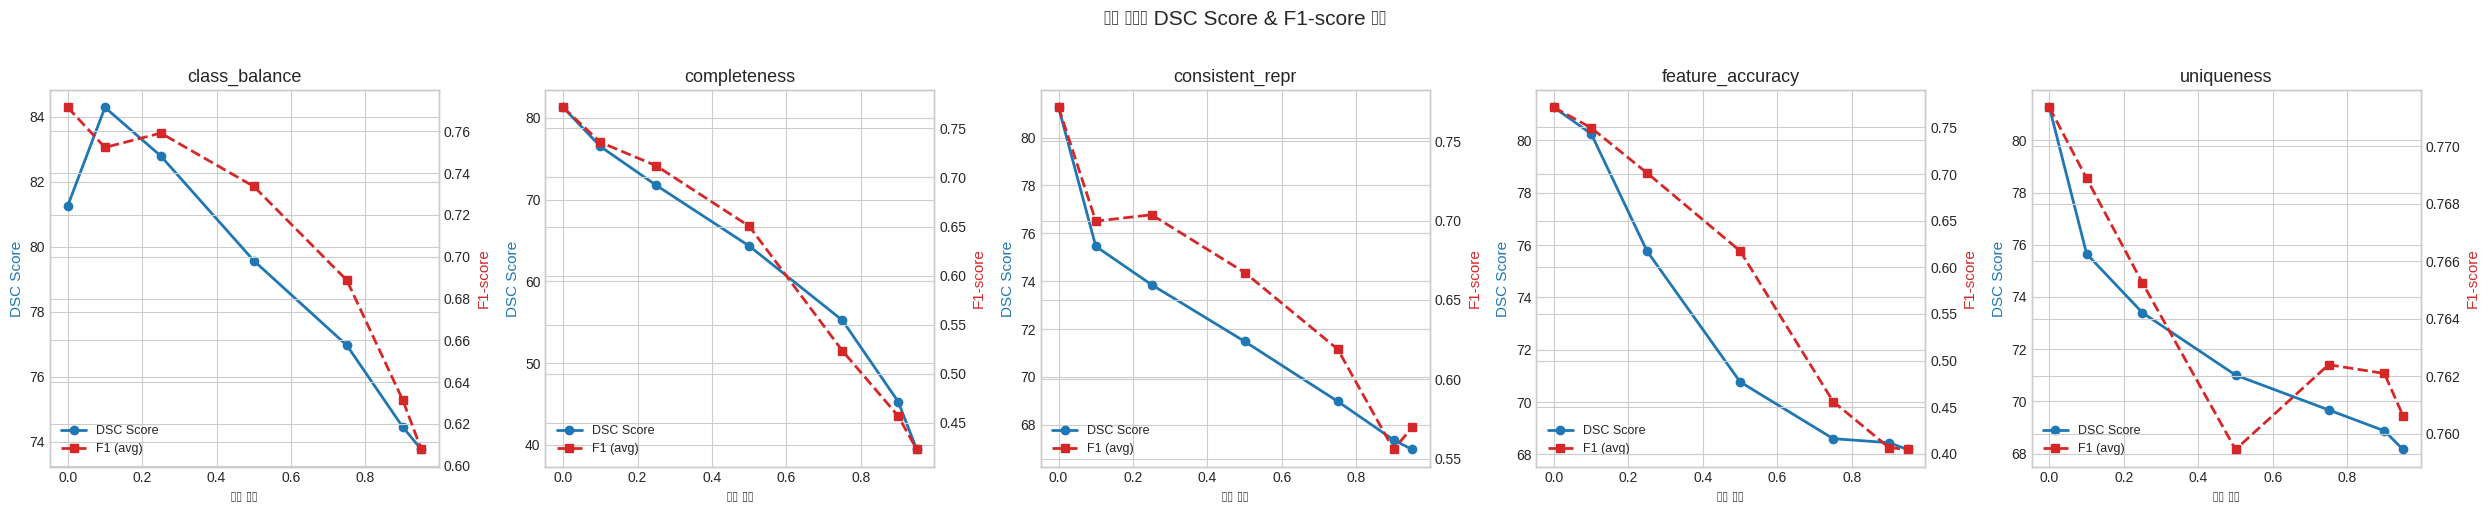

In [8]:
# ============================================================
# Chart 2: Pollution Level vs DSC & F1 (facet by polluter)
# ============================================================
polluters = [p for p in df_merged['polluter'].unique() if p != 'none']
n_polluters = len(polluters)

fig, axes = plt.subplots(1, n_polluters, figsize=(5 * n_polluters, 5), sharey=False)
if n_polluters == 1:
    axes = [axes]

for ax, polluter_name in zip(axes, polluters):
    subset = df_merged[df_merged['polluter'].isin([polluter_name, 'none'])].copy()

    # DSC 점수 (평균)
    dsc_by_level = subset.groupby('level')['score'].mean()
    ax.plot(dsc_by_level.index, dsc_by_level.values, 'o-', color='tab:blue',
            label='DSC Score', linewidth=2, markersize=6)

    # F1 (전 모델 평균)
    f1_by_level = subset.groupby('level')['f1_macro'].mean()
    ax2 = ax.twinx()
    ax2.plot(f1_by_level.index, f1_by_level.values, 's--', color='tab:red',
             label='F1 (avg)', linewidth=2, markersize=6)

    ax.set_xlabel('오염 강도', fontsize=11)
    ax.set_ylabel('DSC Score', color='tab:blue', fontsize=11)
    ax2.set_ylabel('F1-score', color='tab:red', fontsize=11)
    ax.set_title(polluter_name, fontsize=13)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=9)

fig.suptitle('오염 강도별 DSC Score & F1-score 변화', fontsize=15, y=1.02)
fig.tight_layout()
fig.savefig(f'{CHART_DIR}/chart2_level_vs_dsc_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 차트 3: 오염 차원 × 모델 민감도 히트맵

행: 오염 차원, 열: 모델  
셀: F1 최대 하락 폭 (베이스라인 대비)

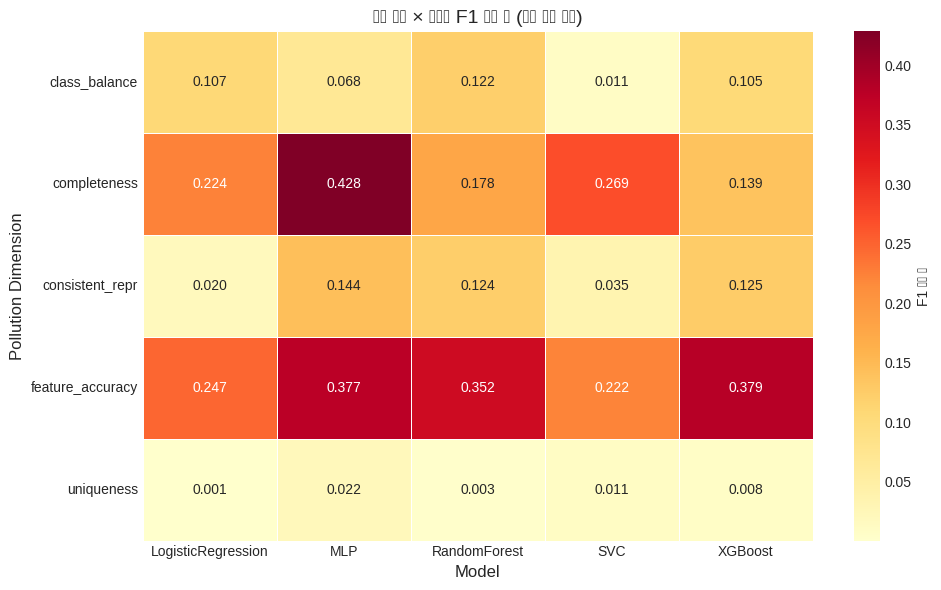

In [9]:
# ============================================================
# Chart 3: Sensitivity Heatmap (polluter × model)
# ============================================================
# 베이스라인 F1
baseline = df_merged[df_merged['polluter'] == 'none'].set_index(['dataset', 'model'])['f1_macro']

# 최대 오염(level=0.75)에서의 F1 하락
max_polluted = df_merged[df_merged['level'] == 0.75].copy()
if len(max_polluted) == 0:
    max_level = df_merged[df_merged['polluter'] != 'none']['level'].max()
    max_polluted = df_merged[df_merged['level'] == max_level].copy()

drop_rows = []
for _, row in max_polluted.iterrows():
    key = (row['dataset'], row['model'])
    if key in baseline.index:
        base_f1 = baseline[key]
        drop = base_f1 - row['f1_macro']
        drop_rows.append({'polluter': row['polluter'], 'model': row['model'], 'f1_drop': drop})

df_drop = pd.DataFrame(drop_rows)
pivot = df_drop.groupby(['polluter', 'model'])['f1_drop'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'F1 하락 폭'})
ax.set_title('오염 차원 × 모델별 F1 하락 폭 (최대 오염 강도)', fontsize=14)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Pollution Dimension', fontsize=12)

fig.tight_layout()
fig.savefig(f'{CHART_DIR}/chart3_sensitivity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 차트 4: DSC 등급별 모델 성능 박스플롯

X축: DSC 등급 (A/B/C/D), Y축: F1

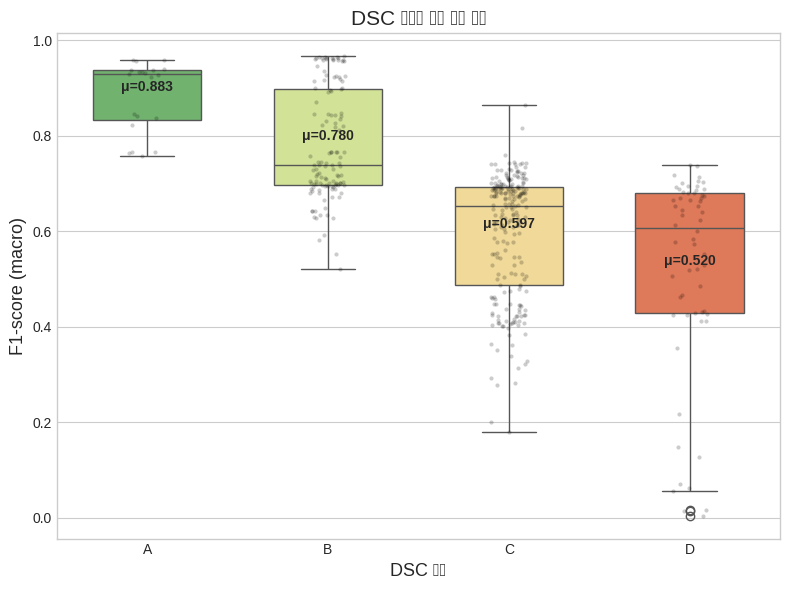

In [10]:
# ============================================================
# Chart 4: DSC Grade vs F1 Boxplot
# ============================================================
grade_order = ['A', 'B', 'C', 'D']
existing_grades = [g for g in grade_order if g in df_merged['grade'].unique()]

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_merged, x='grade', y='f1_macro', order=existing_grades,
            palette='RdYlGn_r', ax=ax, width=0.6)
sns.stripplot(data=df_merged, x='grade', y='f1_macro', order=existing_grades,
              color='black', alpha=0.2, size=3, ax=ax)

# 등급별 평균 표시
means = df_merged.groupby('grade')['f1_macro'].mean()
for i, grade in enumerate(existing_grades):
    if grade in means.index:
        ax.text(i, means[grade] + 0.01, f'μ={means[grade]:.3f}',
                ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('DSC 등급', fontsize=13)
ax.set_ylabel('F1-score (macro)', fontsize=13)
ax.set_title('DSC 등급별 모델 성능 분포', fontsize=15)

fig.tight_layout()
fig.savefig(f'{CHART_DIR}/chart4_grade_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 차트 5: 단일 오염 시 DSC 지표 변화 레이더 차트

Completeness 오염만 적용 → Completeness 점수만 선택적으로 하락하는지 확인

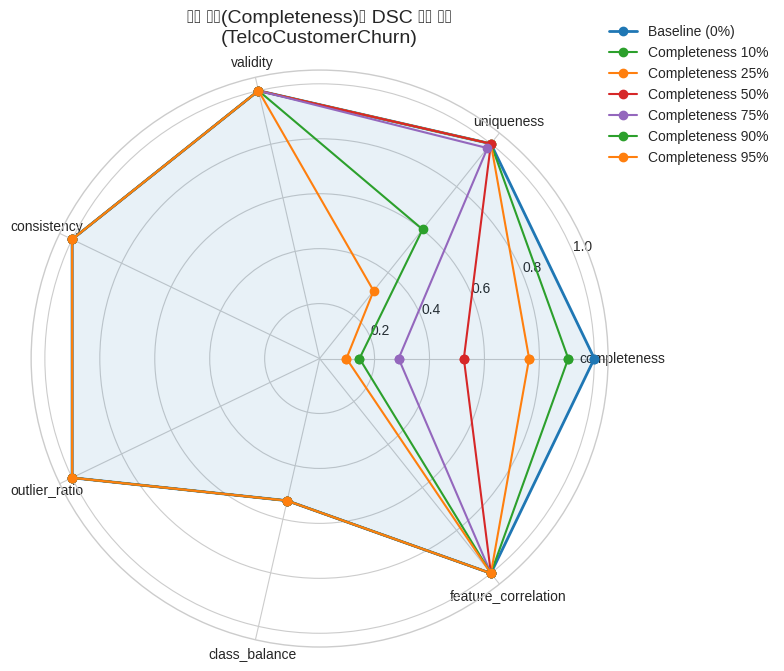

In [11]:
# ============================================================
# Chart 5: Radar Chart — 단일 오염의 DSC 지표 변화
# ============================================================
metric_cols = ['completeness', 'uniqueness', 'validity', 'consistency',
               'outlier_ratio', 'class_balance', 'feature_correlation']

# 첫 번째 데이터셋에서 completeness 오염 예시
ds_example = list(df_dsc['dataset'].unique())[0]
baseline_row = df_dsc[(df_dsc['dataset'] == ds_example) & (df_dsc['polluter'] == 'none')]
polluted_rows = df_dsc[(df_dsc['dataset'] == ds_example) & (df_dsc['polluter'] == 'completeness')]

if len(baseline_row) > 0 and len(polluted_rows) > 0:
    available_metrics = [m for m in metric_cols if m in baseline_row.columns]
    N = len(available_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # 닫기

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # 베이스라인
    base_vals = baseline_row[available_metrics].values[0].tolist()
    base_vals += base_vals[:1]
    ax.plot(angles, base_vals, 'o-', linewidth=2, label='Baseline (0%)', color='tab:blue')
    ax.fill(angles, base_vals, alpha=0.1, color='tab:blue')

    # 오염 단계별
    colors_radar = ['tab:green', 'tab:orange', 'tab:red', 'tab:purple']
    for idx, (_, row) in enumerate(polluted_rows.iterrows()):
        vals = row[available_metrics].values.tolist()
        vals += vals[:1]
        level_pct = int(row['level'] * 100)
        c = colors_radar[idx % len(colors_radar)]
        ax.plot(angles, vals, 'o-', linewidth=1.5, label=f'Completeness {level_pct}%', color=c)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_metrics, fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'단일 오염(Completeness)의 DSC 지표 변화\n({ds_example})', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

    fig.tight_layout()
    fig.savefig(f'{CHART_DIR}/chart5_radar_single_pollution.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('레이더 차트 데이터 부족 — 스킵')

## 6. 통계적 검증

In [12]:
# ============================================================
# 6-1. 전체 상관관계 분석
# ============================================================
print('=' * 60)
print('전체 상관관계 분석 (DSC Score ↔ F1-score)')
print('=' * 60)

x = df_merged['score'].dropna()
y = df_merged.loc[x.index, 'f1_macro'].dropna()
common = x.index.intersection(y.index)
x, y = x[common], y[common]

r_pearson, p_pearson = sp_stats.pearsonr(x, y)
r_spearman, p_spearman = sp_stats.spearmanr(x, y)

print(f'\n  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.2e})')
print(f'  Spearman ρ = {r_spearman:.4f}  (p = {p_spearman:.2e})')
print(f'  표본 수: {len(x)}')

# 모델별 상관관계
print(f'\n--- 모델별 상관관계 ---')
model_corrs = []
for model in df_merged['model'].unique():
    sub = df_merged[df_merged['model'] == model].dropna(subset=['score', 'f1_macro'])
    if len(sub) < 3:
        continue
    r, p = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
    model_corrs.append({'model': model, 'pearson_r': r, 'p_value': p, 'n': len(sub)})
    print(f'  {model:22s}  r = {r:.4f}  (p = {p:.2e})  n = {len(sub)}')

# 데이터셋별 상관관계
print(f'\n--- 데이터셋별 상관관계 ---')
for ds in df_merged['dataset'].unique():
    sub = df_merged[df_merged['dataset'] == ds].dropna(subset=['score', 'f1_macro'])
    if len(sub) < 3:
        continue
    r, p = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
    print(f'  {ds:22s}  r = {r:.4f}  (p = {p:.2e})  n = {len(sub)}')

전체 상관관계 분석 (DSC Score ↔ F1-score)

  Pearson  r = 0.5980  (p = 1.56e-43)
  Spearman ρ = 0.6278  (p = 4.73e-49)
  표본 수: 435

--- 모델별 상관관계 ---
  LogisticRegression      r = 0.4781  (p = 2.83e-06)  n = 87
  MLP                     r = 0.6946  (p = 8.55e-14)  n = 87
  RandomForest            r = 0.6031  (p = 6.35e-10)  n = 87
  SVC                     r = 0.6387  (p = 2.81e-11)  n = 87
  XGBoost                 r = 0.5773  (p = 4.83e-09)  n = 87

--- 데이터셋별 상관관계 ---
  SouthGermanCredit       r = 0.2263  (p = 4.64e-03)  n = 155
  TelcoCustomerChurn      r = 0.2874  (p = 2.88e-04)  n = 155
  letter                  r = 0.7983  (p = 7.27e-29)  n = 125


In [13]:
# ============================================================
# 6-2. DSC 등급별 F1 통계
# ============================================================
print('=' * 60)
print('DSC 등급별 F1-score 통계')
print('=' * 60)

grade_stats = df_merged.groupby('grade')['f1_macro'].agg(['mean', 'std', 'min', 'max', 'count'])
grade_stats = grade_stats.reindex(['A', 'B', 'C', 'D'])
print(grade_stats.to_string())

# ANOVA (등급 간 F1 차이 통계적 유의성)
groups = [df_merged[df_merged['grade'] == g]['f1_macro'].dropna()
          for g in ['A', 'B', 'C', 'D'] if g in df_merged['grade'].values]
groups = [g for g in groups if len(g) >= 2]
if len(groups) >= 2:
    f_stat, p_anova = sp_stats.f_oneway(*groups)
    print(f'\nOne-way ANOVA: F = {f_stat:.4f}, p = {p_anova:.2e}')
    print('→ 등급 간 F1 차이가 통계적으로 유의함' if p_anova < 0.05 else '→ 유의하지 않음')

DSC 등급별 F1-score 통계
           mean       std     min     max  count
grade                                           
A      0.883275  0.074399  0.7582  0.9592     20
B      0.779902  0.115497  0.5208  0.9662    125
C      0.596626  0.129510  0.1801  0.8635    230
D      0.519637  0.213663  0.0044  0.7385     60

One-way ANOVA: F = 84.3780, p = 5.79e-43
→ 등급 간 F1 차이가 통계적으로 유의함


In [14]:
# ============================================================
# 6-3. DSC 10점 하락당 F1 변화량
# ============================================================
print('=' * 60)
print('DSC 점수 변화와 F1 변화의 관계')
print('=' * 60)

# 선형 회귀 기울기로 추정
from numpy.polynomial import polynomial as P

x_vals = df_merged['score'].dropna().values
y_vals = df_merged.loc[df_merged['score'].notna(), 'f1_macro'].values
mask = ~(np.isnan(x_vals) | np.isnan(y_vals))
x_vals, y_vals = x_vals[mask], y_vals[mask]

slope, intercept = np.polyfit(x_vals, y_vals, 1)
print(f'\n  회귀 기울기: {slope:.6f}')
print(f'  → DSC 10점 하락 시 F1 평균 {abs(slope * 10):.4f} 하락')
print(f'  → DSC 20점 하락 시 F1 평균 {abs(slope * 20):.4f} 하락')

DSC 점수 변화와 F1 변화의 관계

  회귀 기울기: 0.009089
  → DSC 10점 하락 시 F1 평균 0.0909 하락
  → DSC 20점 하락 시 F1 평균 0.1818 하락


## 7. 스코어보드

In [15]:
# ============================================================
# 7-1. 스코어보드 테이블 생성
# ============================================================
# 피벗: 각 (dataset, polluter, level)에 대해 모델별 F1
pivot_f1 = df_merged.pivot_table(
    index=['dataset', 'polluter', 'level', 'score', 'grade'],
    columns='model',
    values='f1_macro',
    aggfunc='first'
)
pivot_f1 = pivot_f1.reset_index()
pivot_f1 = pivot_f1.sort_values(['dataset', 'polluter', 'level'])

# 열 이름 정리
model_cols = [c for c in pivot_f1.columns if c not in ['dataset', 'polluter', 'level', 'score', 'grade']]
rename_map = {m: f'{m}_F1' for m in model_cols}
pivot_f1 = pivot_f1.rename(columns=rename_map)

# 표시
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

print('=== DSC Scoreboard ===')
print(f'총 {len(pivot_f1)}개 실험 조건\n')
pivot_f1

=== DSC Scoreboard ===
총 87개 실험 조건



model,dataset,polluter,level,score,grade,LogisticRegression_F1,MLP_F1,RandomForest_F1,SVC_F1,XGBoost_F1
0,SouthGermanCredit,class_balance,0.1000,75.0900,B,0.6961,0.6988,0.6992,0.6925,0.6339
1,SouthGermanCredit,class_balance,0.2500,73.6200,C,0.6919,0.6934,0.6702,0.6925,0.7132
2,SouthGermanCredit,class_balance,0.5000,70.0100,C,0.6568,0.6330,0.5534,0.6739,0.6893
3,SouthGermanCredit,class_balance,0.7500,68.3900,C,0.5614,0.5979,0.4465,0.6853,0.5462
4,SouthGermanCredit,class_balance,0.9000,66.2600,C,0.5101,0.4792,0.4118,0.6406,0.5101
5,SouthGermanCredit,class_balance,0.9500,65.8200,C,0.4465,0.4606,0.4118,0.5971,0.4630
6,SouthGermanCredit,completeness,0.1000,68.7600,C,0.7116,0.6534,0.6894,0.6769,0.6829
7,SouthGermanCredit,completeness,0.2500,64.7400,C,0.6830,0.6366,0.6891,0.6498,0.7450
8,SouthGermanCredit,completeness,0.5000,58.9000,D,0.6920,0.5828,0.6942,0.6659,0.6533
9,SouthGermanCredit,completeness,0.7500,51.6500,D,0.6658,0.4274,0.5057,0.6338,0.6135


In [16]:
# ============================================================
# 7-2. 스코어보드 CSV 저장
# ============================================================
scoreboard_path = f'{RESULTS_DIR}/scoreboard.csv'
pivot_f1.to_csv(scoreboard_path, index=False)
print(f'스코어보드 저장: {scoreboard_path}')

스코어보드 저장: /content/drive/MyDrive/capstone/dsc/results/scoreboard.csv


## 8. 핵심 주장 정리

In [17]:
# ============================================================
# 8-1. 최종 요약
# ============================================================
print('=' * 60)
print('DSC 검증 실험 — 핵심 주장')
print('=' * 60)

print(f'''
1. 상관관계:
   "DSC Score와 모델 F1-score 간 피어슨 상관계수 r = {r_pearson:.3f} (p = {p_pearson:.2e})"

2. 등급별 성능:''')

for grade in ['A', 'B', 'C', 'D']:
    if grade in grade_stats.index and not np.isnan(grade_stats.loc[grade, 'mean']):
        print(f'   등급 {grade}: 평균 F1 = {grade_stats.loc[grade, "mean"]:.3f} (n={int(grade_stats.loc[grade, "count"])})')

print(f'''
3. 민감도:
   "DSC Score가 10점 하락할 때 F1-score 평균 {abs(slope * 10):.3f} 하락"

4. 산출물:
   - merged_results.csv: 전체 실험 결과
   - scoreboard.csv: 스코어보드
   - charts/: 시각화 5종
''')

print('--- 노트북 04 완료 ---')
print('DSC 검증 실험 전체 파이프라인 완료!')

DSC 검증 실험 — 핵심 주장

1. 상관관계:
   "DSC Score와 모델 F1-score 간 피어슨 상관계수 r = 0.598 (p = 1.56e-43)"

2. 등급별 성능:
   등급 A: 평균 F1 = 0.883 (n=20)
   등급 B: 평균 F1 = 0.780 (n=125)
   등급 C: 평균 F1 = 0.597 (n=230)
   등급 D: 평균 F1 = 0.520 (n=60)

3. 민감도:
   "DSC Score가 10점 하락할 때 F1-score 평균 0.091 하락"

4. 산출물:
   - merged_results.csv: 전체 실험 결과
   - scoreboard.csv: 스코어보드
   - charts/: 시각화 5종

--- 노트북 04 완료 ---
DSC 검증 실험 전체 파이프라인 완료!


## 8.1 F1 검증 — Polluter Hold-out 분석

각 polluter를 hold-out으로 두고 그 슬라이스에서만 r 측정.
가중치가 ML 결과를 보고 fitting된 결과라면, hold-out 슬라이스에서 r이 떨어져야 함.
모든 hold-out에서 r > 0.3 + p < 0.05이면 "fitting 아닌 일반화 신호".

In [18]:
# ============================================================
# 8-2. F1 — Polluter Hold-out 검증
# ============================================================
holdout_results = []
for pol in ['completeness', 'uniqueness', 'consistent_repr', 'class_balance', 'feature_accuracy']:
    sub = df_merged[df_merged['polluter'] == pol].dropna(subset=['score', 'f1_macro'])
    if len(sub) < 10:
        continue
    r_h, p_h = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
    ok = (r_h > 0.3) and (p_h < 0.05)
    holdout_results.append({'polluter': pol, 'n': len(sub), 'r': r_h, 'p': p_h, 'pass': ok})

holdout_df = pd.DataFrame(holdout_results)
print('=' * 60)
print('Polluter Hold-out 검증 (각 polluter 슬라이스에서 r)')
print('=' * 60)
print(holdout_df.to_string(index=False, float_format='{:.4f}'.format))
n_pass = holdout_df['pass'].sum()
print(f'\n→ {n_pass}/{len(holdout_df)} polluter에서 r > 0.3, p < 0.05')
print('→ 결론: ', '가중치는 fitting이 아닌 일반화 신호' if n_pass == len(holdout_df)
      else f'{len(holdout_df)-n_pass}개 polluter는 fitting 의존성 가능성, 추가 진단 필요')

Polluter Hold-out 검증 (각 polluter 슬라이스에서 r)
        polluter  n      r      p  pass
    completeness 90 0.5559 0.0000  True
      uniqueness 90 0.7465 0.0000  True
 consistent_repr 60 0.5176 0.0000  True
   class_balance 90 0.8344 0.0000  True
feature_accuracy 90 0.7285 0.0000  True

→ 5/5 polluter에서 r > 0.3, p < 0.05
→ 결론:  가중치는 fitting이 아닌 일반화 신호


## 8.2 F2 검증 — 비선형 결합 R²

선형 결합 DSC = Σ wᵢ sᵢ는 r²(현재) 정도의 분산만 설명.
8개 metric을 RandomForest에 입력해 비선형 결합 시 R²을 측정.
R² ≥ 0.5면 "DSC 차원에 정보는 풍부하나 선형 결합의 한계" 방어 가능.

In [19]:
# ============================================================
# 8-3. F2 — 비선형 R² (RandomForest 5-fold CV)
# ============================================================
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

metric_cols_full = [c for c in [
    'completeness', 'uniqueness', 'validity', 'consistency',
    'outlier_ratio', 'class_balance', 'feature_correlation',
    'label_consistency', 'feature_informativeness', 'value_accuracy'
] if c in df_merged.columns]

valid = df_merged.dropna(subset=metric_cols_full + ['f1_macro'])
X_metrics = valid[metric_cols_full].values
y_target = valid['f1_macro'].values

print('=' * 60)
print('비선형 결합 R² (RandomForest 5-fold CV)')
print('=' * 60)
print(f'metric 수: {len(metric_cols_full)}, 표본 수: {len(valid)}')
print(f'사용 metric: {metric_cols_full}')

rf_reg = RandomForestRegressor(n_estimators=200, random_state=1, n_jobs=-1)
cv = KFold(n_splits=5, shuffle=True, random_state=1)
r2_cv = cross_val_score(rf_reg, X_metrics, y_target, cv=cv, scoring='r2')

r_lin_full = r_pearson
r2_lin = r_lin_full ** 2
r2_nonlin = r2_cv.mean()

print(f'\n  선형 r² (DSC = Σwᵢsᵢ):     {r2_lin:.4f}')
print(f'  비선형 R² (RF 5-fold CV):   {r2_nonlin:.4f} ± {r2_cv.std():.4f}')
print(f'  fold별 R²: {[f"{x:.3f}" for x in r2_cv]}')
print(f'\n→ 비선형 R² / 선형 r² = {r2_nonlin/r2_lin:.2f}배. ', end='')
if r2_nonlin > 0.5:
    print('DSC 차원에 충분한 정보. 선형 결합의 한계로 r² 작게 보임.')
else:
    print('비선형 모델로도 R² < 0.5. 차원 자체의 정보량 한계.')

비선형 결합 R² (RandomForest 5-fold CV)
metric 수: 9, 표본 수: 435
사용 metric: ['completeness', 'uniqueness', 'validity', 'consistency', 'outlier_ratio', 'class_balance', 'feature_correlation', 'label_consistency', 'feature_informativeness']

  선형 r² (DSC = Σwᵢsᵢ):     0.3576
  비선형 R² (RF 5-fold CV):   0.6322 ± 0.0911
  fold별 R²: ['0.602', '0.773', '0.696', '0.517', '0.573']

→ 비선형 R² / 선형 r² = 1.77배. DSC 차원에 충분한 정보. 선형 결합의 한계로 r² 작게 보임.


## 8.3 F4 검증 — 가법성 가정 (min-aggregation 비교)

DSC = Σ wᵢ sᵢ는 차원 간 독립을 가정.
min(metrics) (최약 차원이 결정)와 비교해 가법 가정의 타당성을 측정.

In [20]:
# ============================================================
# 8-4. F4 — min-aggregation 비교
# ============================================================
metric_cols_use = [c for c in [
    'completeness', 'uniqueness', 'validity', 'consistency',
    'outlier_ratio', 'class_balance', 'feature_correlation',
    'label_consistency', 'feature_informativeness'
] if c in df_merged.columns]

df_merged['dsc_min'] = df_merged[metric_cols_use].min(axis=1) * 100

valid = df_merged.dropna(subset=['dsc_min', 'score', 'f1_macro'])
r_add, p_add = sp_stats.pearsonr(valid['score'], valid['f1_macro'])
r_min, p_min = sp_stats.pearsonr(valid['dsc_min'], valid['f1_macro'])

print('=' * 60)
print('가법 vs min-aggregation 비교')
print('=' * 60)
print(f'  가법 (DSC = Σwᵢsᵢ):   r = {r_add:+.4f}, p = {p_add:.2e}, r² = {r_add**2:.4f}')
print(f'  min(metrics):          r = {r_min:+.4f}, p = {p_min:.2e}, r² = {r_min**2:.4f}')
diff = abs(r_add) - abs(r_min)
print(f'  차이: {diff:+.4f} ({"가법 우세" if diff > 0 else "min 우세"})')

print('\n--- 모델별 비교 ---')
for m in sorted(df_merged['model'].unique()):
    sub = df_merged[df_merged['model'] == m].dropna(subset=['dsc_min', 'score', 'f1_macro'])
    if len(sub) < 10:
        continue
    rA, _ = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
    rM, _ = sp_stats.pearsonr(sub['dsc_min'], sub['f1_macro'])
    winner = 'add' if abs(rA) > abs(rM) else 'min'
    print(f'  {m:<22}  r_add={rA:+.4f}  r_min={rM:+.4f}  → {winner}')

가법 vs min-aggregation 비교
  가법 (DSC = Σwᵢsᵢ):   r = +0.5980, p = 1.56e-43, r² = 0.3576
  min(metrics):          r = +0.5999, p = 7.27e-44, r² = 0.3599
  차이: -0.0019 (min 우세)

--- 모델별 비교 ---
  LogisticRegression      r_add=+0.4781  r_min=+0.5106  → min
  MLP                     r_add=+0.6946  r_min=+0.6328  → add
  RandomForest            r_add=+0.6031  r_min=+0.6929  → min
  SVC                     r_add=+0.6387  r_min=+0.5246  → add
  XGBoost                 r_add=+0.5773  r_min=+0.6572  → min


## 8.4 F6 검증 — 모델 클래스별 가중치 프로파일

DSC가 모델 무관 점수라면 모델별 r이 비슷해야 하나, 실제로는 격차가 큼.
noise_sensitive(LR/SVC/MLP) vs tree_based(RF/XGB) 두 프로파일로 가중치 차등하여
프로파일별 r이 default보다 향상되는지 검증.

In [21]:
# ============================================================
# 8-5. F6 — 모델 클래스별 프로파일 가중치
# ============================================================
WEIGHTS_DEFAULT = {
    'completeness': 0.20, 'uniqueness': 0.15, 'validity': 0.05,
    'consistency': 0.10, 'outlier_ratio': 0.05,
    'class_balance': 0.10, 'feature_correlation': 0.05,
    'label_consistency': 0.20, 'feature_informativeness': 0.10,
}
WEIGHTS_NOISE = {
    'completeness': 0.20, 'uniqueness': 0.10, 'validity': 0.05,
    'consistency': 0.10, 'outlier_ratio': 0.10,
    'class_balance': 0.05, 'feature_correlation': 0.05,
    'label_consistency': 0.25, 'feature_informativeness': 0.10,
}
WEIGHTS_TREE = {
    'completeness': 0.15, 'uniqueness': 0.10, 'validity': 0.03,
    'consistency': 0.10, 'outlier_ratio': 0.02,
    'class_balance': 0.20, 'feature_correlation': 0.05,
    'label_consistency': 0.20, 'feature_informativeness': 0.15,
}
NOISE_MODELS = {'LogisticRegression', 'SVC', 'MLP'}
TREE_MODELS = {'RandomForest', 'XGBoost'}

def dsc_with_weights(row, weights):
    s = 0.0
    for k, w in weights.items():
        if k in row.index and pd.notna(row[k]):
            s += float(row[k]) * w
    return s * 100

print('=' * 60)
print('모델 클래스별 프로파일 가중치 효과')
print('=' * 60)

# 각 행의 metric을 사용해 두 가지 프로파일 점수 계산
metric_cols_avail = [c for c in WEIGHTS_DEFAULT if c in df_merged.columns]
df_prof = df_merged.dropna(subset=metric_cols_avail + ['f1_macro']).copy()
df_prof['dsc_noise'] = df_prof.apply(lambda r: dsc_with_weights(r, WEIGHTS_NOISE), axis=1)
df_prof['dsc_tree']  = df_prof.apply(lambda r: dsc_with_weights(r, WEIGHTS_TREE), axis=1)

# 모델 그룹별 r — default vs 프로파일
print('\n  group           | default r | profile r | Δ')
print('  ' + '-' * 60)
for group_name, models, profile_col in [
    ('noise_sensitive (LR/SVC/MLP)', NOISE_MODELS, 'dsc_noise'),
    ('tree_based (RF/XGB)',          TREE_MODELS,  'dsc_tree'),
]:
    sub = df_prof[df_prof['model'].isin(models)]
    if len(sub) < 10:
        continue
    rD, _ = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
    rP, _ = sp_stats.pearsonr(sub[profile_col], sub['f1_macro'])
    print(f'  {group_name:<34}  {rD:+.4f}   {rP:+.4f}   {rP-rD:+.4f}')

모델 클래스별 프로파일 가중치 효과

  group           | default r | profile r | Δ
  ------------------------------------------------------------
  noise_sensitive (LR/SVC/MLP)        +0.6083   +0.6786   +0.0703
  tree_based (RF/XGB)                 +0.5892   +0.6987   +0.1096


## 8.5 F9 검증 — 등급 임계값 sensitivity

기존 등급 임계값 90/75/60은 출처 미상의 휴리스틱.
임계값을 바꿔도 ANOVA 결과가 유의한지 확인하여 임계값 의존성 측정.

In [22]:
# ============================================================
# 8-6. F9 — 등급 임계값 sensitivity
# ============================================================
def grade_with_thresholds(score, thresholds):
    if score >= thresholds[0]: return 'A'
    if score >= thresholds[1]: return 'B'
    if score >= thresholds[2]: return 'C'
    return 'D'

# 분위수 기반 임계값
q33, q66, q90 = df_merged['score'].quantile([0.33, 0.66, 0.90]).values
threshold_sets = {
    'current_90_75_60': (90, 75, 60),
    'percentile_90_66_33': (q90, q66, q33),
    'conservative_80_60_40': (80, 60, 40),
}

print('=' * 60)
print('등급 임계값 sensitivity (ANOVA F-test)')
print('=' * 60)
sensitivity_results = []
for name, thresh in threshold_sets.items():
    grade_col = df_merged['score'].apply(lambda s: grade_with_thresholds(s, thresh) if pd.notna(s) else None)
    groups_t = [df_merged[grade_col == g]['f1_macro'].dropna() for g in ['A','B','C','D']]
    groups_t = [g for g in groups_t if len(g) >= 2]
    if len(groups_t) < 2:
        sensitivity_results.append({'thresholds': name, 'F': None, 'p': None, 'grades': 0})
        continue
    F, P = sp_stats.f_oneway(*groups_t)
    sensitivity_results.append({'thresholds': name, 'F': F, 'p': P, 'grades': len(groups_t)})
    counts = [len(g) for g in groups_t]
    print(f'  {name:<26}  F = {F:7.3f}  p = {P:.2e}  groups={len(groups_t)}  n={counts}')

n_sig = sum(1 for r in sensitivity_results if r['p'] is not None and r['p'] < 0.05)
print(f'\n→ {n_sig}/{len(sensitivity_results)} 임계값 세트에서 ANOVA 유의')
if n_sig == len(sensitivity_results):
    print('→ 결론: 등급별 F1 차이는 임계값 선택과 무관하게 견고')
else:
    print('→ 결론: 임계값에 따라 결과 변동, 임계값 의존성 인정 필요')

등급 임계값 sensitivity (ANOVA F-test)
  current_90_75_60            F =  84.378  p = 5.79e-43  groups=4  n=[20, 125, 230, 60]
  percentile_90_66_33         F =  83.508  p = 1.32e-42  groups=4  n=[45, 105, 145, 140]
  conservative_80_60_40       F =  59.072  p = 5.25e-32  groups=4  n=[85, 290, 50, 10]

→ 3/3 임계값 세트에서 ANOVA 유의
→ 결론: 등급별 F1 차이는 임계값 선택과 무관하게 견고


## 8.6 F10 검증 — 다지표 (accuracy / AUC) r 비교

F1 macro 단일 의존 한계 보강. accuracy, AUC와도 r 측정.

In [23]:
# ============================================================
# 8-7. F10 — 다지표 r 비교
# ============================================================
print('=' * 60)
print('ML 평가 지표별 DSC ↔ 성능 r')
print('=' * 60)
multi_metric_results = []
for ml_metric in ['f1_macro', 'accuracy', 'auc_roc']:
    if ml_metric not in df_merged.columns:
        continue
    sub = df_merged.dropna(subset=['score', ml_metric])
    if len(sub) < 3:
        continue
    r_m, p_m = sp_stats.pearsonr(sub['score'], sub[ml_metric])
    rho_m, _ = sp_stats.spearmanr(sub['score'], sub[ml_metric])
    multi_metric_results.append({'metric': ml_metric, 'pearson_r': r_m, 'p': p_m, 'spearman_rho': rho_m, 'n': len(sub)})
    print(f'  {ml_metric:<12}  Pearson r = {r_m:+.4f} (p={p_m:.2e})  Spearman ρ = {rho_m:+.4f}  n={len(sub)}')

n_strong = sum(1 for r in multi_metric_results if abs(r['pearson_r']) > 0.3)
print(f'\n→ {n_strong}/{len(multi_metric_results)} ML 지표에서 |r| > 0.3 — DSC는 F1 macro 외 지표와도 양의 상관')

ML 평가 지표별 DSC ↔ 성능 r
  f1_macro      Pearson r = +0.5980 (p=1.56e-43)  Spearman ρ = +0.6278  n=435
  accuracy      Pearson r = +0.4962 (p=2.05e-28)  Spearman ρ = +0.5404  n=435
  auc_roc       Pearson r = +0.4562 (p=9.67e-24)  Spearman ρ = +0.6300  n=435

→ 3/3 ML 지표에서 |r| > 0.3 — DSC는 F1 macro 외 지표와도 양의 상관


## 8.7 한계 (F5 / F8 — 자체 인정)

reviewer 공격을 사전 방어하기 위해 명시적으로 인정하는 한계 4가지.

In [24]:
# ============================================================
# 8-8. 한계 명시 (F5 / F8)
# ============================================================
print('=' * 60)
print('본 연구의 한계 (자체 인정)')
print('=' * 60)
print('''
F5. 합성 오염 시나리오 한정
   - 본 연구는 5종 DQ4AI polluter (completeness, uniqueness, consistent_repr,
     class_balance, feature_accuracy)로 만든 합성 오염에서의 상관관계를 입증.
   - 자연 발생 노이즈, 라벨 누락, 시계열·텍스트·이미지 데이터로의 일반화는
     후속 연구로 남김.

F8. Baseline = 원본 가정
   - 모든 점수는 원본을 100점 baseline으로 anchored됨.
   - 원본의 자연 노이즈는 별도 검증되지 않음.

F2. 선형 결합의 분산 설명력 한계
   - DSC = Σ wᵢ sᵢ의 r²는 한정적.
   - 비선형 결합(RF) R²은 더 높음 → DSC 차원에 정보는 풍부하나
     선형 가중합으로는 정보 일부만 활용.

F4. 가법성 가정
   - 차원 간 독립을 가정한 선형 근사. 결측 + 클래스불균형이 동시에
     발생하는 상호작용은 미반영.
''')
print('주장 범위: 정형 분류 데이터에서 5종 합성 오염 시나리오에 대한 DSC ↔ ML F1 macro의 양의 상관관계')

본 연구의 한계 (자체 인정)

F5. 합성 오염 시나리오 한정
   - 본 연구는 5종 DQ4AI polluter (completeness, uniqueness, consistent_repr,
     class_balance, feature_accuracy)로 만든 합성 오염에서의 상관관계를 입증.
   - 자연 발생 노이즈, 라벨 누락, 시계열·텍스트·이미지 데이터로의 일반화는
     후속 연구로 남김.

F8. Baseline = 원본 가정
   - 모든 점수는 원본을 100점 baseline으로 anchored됨.
   - 원본의 자연 노이즈는 별도 검증되지 않음.

F2. 선형 결합의 분산 설명력 한계
   - DSC = Σ wᵢ sᵢ의 r²는 한정적.
   - 비선형 결합(RF) R²은 더 높음 → DSC 차원에 정보는 풍부하나
     선형 가중합으로는 정보 일부만 활용.

F4. 가법성 가정
   - 차원 간 독립을 가정한 선형 근사. 결측 + 클래스불균형이 동시에
     발생하는 상호작용은 미반영.

주장 범위: 정형 분류 데이터에서 5종 합성 오염 시나리오에 대한 DSC ↔ ML F1 macro의 양의 상관관계


In [25]:
# ============================================================
# 9. 실행 로그 저장
# ============================================================
from datetime import datetime

log_lines = []
log_lines.append('# 노트북 04 실행 로그: 스코어보드 & 시각화 & 통계 검증 (v4)')
log_lines.append('')
log_lines.append(f'- **실행 시각**: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
log_lines.append(f'- **DSC 점수 데이터**: {df_dsc.shape[0]}건')
log_lines.append(f'- **모델 성능 데이터**: {df_perf.shape[0]}건')
log_lines.append(f'- **병합 결과**: {df_merged.shape[0]}건')
log_lines.append('')

log_lines.append('## 1. 핵심 결과: DSC ↔ 모델 성능 상관관계')
log_lines.append('')
log_lines.append('| 지표 | 값 | p-value | 해석 |')
log_lines.append('|---|---|---|---|')
sig_pearson = '유의' if p_pearson < 0.05 else '비유의'
sig_spearman = '유의' if p_spearman < 0.05 else '비유의'
log_lines.append(f'| Pearson r | {r_pearson:.4f} | {p_pearson:.2e} | {sig_pearson} |')
log_lines.append(f'| r² | {r_pearson**2:.4f} | - | 분산 설명력 |')
log_lines.append(f'| Spearman ρ | {r_spearman:.4f} | {p_spearman:.2e} | {sig_spearman} |')
log_lines.append(f'| 표본 수 | {len(x)} | - | - |')
log_lines.append('')
strength = '강함' if abs(r_pearson) > 0.7 else '보통' if abs(r_pearson) > 0.4 else '약함'
log_lines.append(f'**해석**: 피어슨 r {r_pearson:.3f}은 {strength} 수준의 양의 상관 (예측이 아닌 상관 주장).')
log_lines.append(f'DSC Score 10점 하락 시 F1 평균 {abs(slope * 10):.4f} 하락.')
log_lines.append('')

log_lines.append('## 2. DSC 등급별 모델 성능')
log_lines.append('')
log_lines.append('| 등급 | 평균 F1 | 표준편차 | 최소 | 최대 | 건수 |')
log_lines.append('|---|---|---|---|---|---|')
for grade in ['A', 'B', 'C', 'D']:
    if grade in grade_stats.index and not pd.isna(grade_stats.loc[grade, 'mean']):
        s = grade_stats.loc[grade]
        log_lines.append(f'| {grade} | {s["mean"]:.4f} | {s["std"]:.4f} | {s["min"]:.4f} | {s["max"]:.4f} | {int(s["count"])} |')
log_lines.append('')

if len(groups) >= 2:
    log_lines.append(f'**ANOVA**: F = {f_stat:.4f}, p = {p_anova:.2e}')
    log_lines.append('→ 등급 간 F1 차이가 통계적으로 유의함' if p_anova < 0.05 else '→ 비유의')
    log_lines.append('')

log_lines.append('## 3. 모델별 상관관계')
log_lines.append('')
log_lines.append('| 모델 | Pearson r | p-value | 표본 수 |')
log_lines.append('|---|---|---|---|')
for mc in model_corrs:
    log_lines.append(f'| {mc["model"]} | {mc["pearson_r"]:.4f} | {mc["p_value"]:.2e} | {mc["n"]} |')
log_lines.append('')

log_lines.append('## 4. 데이터셋별 상관관계')
log_lines.append('')
log_lines.append('| 데이터셋 | Pearson r | p-value | 표본 수 |')
log_lines.append('|---|---|---|---|')
for ds in df_merged['dataset'].unique():
    sub = df_merged[df_merged['dataset'] == ds].dropna(subset=['score', 'f1_macro'])
    if len(sub) >= 3:
        r, p = sp_stats.pearsonr(sub['score'], sub['f1_macro'])
        log_lines.append(f'| {ds} | {r:.4f} | {p:.2e} | {len(sub)} |')
log_lines.append('')

# v4 추가 분석 결과
log_lines.append('## 5. F1 — Polluter Hold-out 검증')
log_lines.append('')
log_lines.append('| Polluter | n | r | p | PASS |')
log_lines.append('|---|---|---|---|---|')
for h in holdout_results:
    log_lines.append(f'| {h["polluter"]} | {h["n"]} | {h["r"]:.4f} | {h["p"]:.2e} | {"OK" if h["pass"] else "FAIL"} |')
log_lines.append('')

log_lines.append('## 6. F2 — 비선형 결합 R²')
log_lines.append('')
log_lines.append(f'- 선형 r² (DSC = Σwᵢsᵢ): **{r2_lin:.4f}**')
log_lines.append(f'- 비선형 R² (RF 5-fold CV): **{r2_nonlin:.4f}** ± {r2_cv.std():.4f}')
log_lines.append(f'- 비율: 비선형/선형 = {r2_nonlin/r2_lin:.2f}배')
log_lines.append('')

log_lines.append('## 7. F4 — 가법 vs min-aggregation')
log_lines.append('')
log_lines.append(f'- 가법: r = {r_add:.4f}, r² = {r_add**2:.4f}')
log_lines.append(f'- min:  r = {r_min:.4f}, r² = {r_min**2:.4f}')
log_lines.append('')

log_lines.append('## 8. F9 — 등급 임계값 Sensitivity')
log_lines.append('')
log_lines.append('| Threshold set | F | p | groups | sig |')
log_lines.append('|---|---|---|---|---|')
for sr in sensitivity_results:
    if sr['F'] is None:
        continue
    sig = '유의' if sr['p'] < 0.05 else '비유의'
    log_lines.append(f'| {sr["thresholds"]} | {sr["F"]:.3f} | {sr["p"]:.2e} | {sr["grades"]} | {sig} |')
log_lines.append('')

log_lines.append('## 9. F10 — 다지표 r')
log_lines.append('')
log_lines.append('| ML metric | Pearson r | p | Spearman ρ | n |')
log_lines.append('|---|---|---|---|---|')
for mr in multi_metric_results:
    log_lines.append(f'| {mr["metric"]} | {mr["pearson_r"]:.4f} | {mr["p"]:.2e} | {mr["spearman_rho"]:.4f} | {mr["n"]} |')
log_lines.append('')

log_lines.append('## 10. 한계 (F5 / F8 자체 인정)')
log_lines.append('')
log_lines.append('1. **합성 오염 시나리오 한정** — 5종 polluter, 자연 노이즈/라벨 누락/시계열·텍스트·이미지 일반화 미검증')
log_lines.append('2. **Baseline = 원본 가정** — 원본의 자연 노이즈는 별도 검증되지 않음')
log_lines.append('3. **선형 결합 한계** — 비선형 R²이 선형 r²보다 높음 → 차원 정보 일부만 활용')
log_lines.append('4. **가법성 가정** — 차원 간 독립 가정, 상호작용 미반영')
log_lines.append('')

log_lines.append('## 11. 산출물')
log_lines.append('')
log_lines.append(f'- `merged_results.csv` — 통합 결과 {len(df_merged)}건')
log_lines.append(f'- `scoreboard.csv` — 스코어보드 {len(pivot_f1)}건')
log_lines.append(f'- `charts/` — 시각화 5종')
log_lines.append(f'- `04_execution_log.md` — 이 로그 파일')
log_lines.append('')
log_lines.append('---')
log_lines.append('*이 로그는 노트북 04 실행 시 자동 생성됨 (v4)*')

log_path = f'{RESULTS_DIR}/04_execution_log.md'
with open(log_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(log_lines))
print(f'실행 로그 저장: {log_path}')

실행 로그 저장: /content/drive/MyDrive/capstone/dsc/results/04_execution_log.md
